# RDX — Representational Difference Explanations

### Kondapaneni, Mac Aodha, Perona · NeurIPS 2025

This notebook reproduces the **MNIST-[3,5,8]** comparison from §4.2 of the paper:  
compare a _strong_ checkpoint (M*S, 95% acc) with an \_expert* checkpoint (M_E, 98% acc)  
and recover the representational differences using RDX.

**Structure:**

1. Setup & imports
2. Dataset — MNIST digits {3, 5, 8}
3. Model — small 2-layer CNN (matches paper exactly)
4. Training — two checkpoints (epoch 1 vs epoch 5)
5. Extract embeddings
6. **RDX pipeline** — distances → difference matrix → affinity → spectral clustering → KNA sampling
7. Display explanation grids
8. Evaluate with BSR metric

---

> **Environment:** Requires `torch`, `torchvision`, `scikit-learn`, `matplotlib`.  
> Install with: `pip install torch torchvision scikit-learn matplotlib`


## 1 · Imports & Setup


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as T

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.cluster import SpectralClustering

from dataclasses import dataclass
from typing import Optional
import warnings
warnings.filterwarnings("ignore")

# ── RDX repository import ──────────────────────────────────────────────────
import sys, os
_rdx_repo_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "RDX")
if _rdx_repo_path not in sys.path:
    sys.path.insert(0, _rdx_repo_path)
from src.rdx import RDX as RDXRepo

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 4834586          # exact seed from the paper (§C.1)
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
print(f"PyTorch {torch.__version__} | torchvision {torchvision.__version__}")

Using device: cuda
PyTorch 2.10.0+cu128 | torchvision 0.25.0+cu128


## 2 · Dataset — MNIST {3, 5, 8}

The paper trains on a filtered MNIST containing only digits **3, 5, and 8**.  
These three classes are chosen because they're visually similar (curved strokes)  
making them a good stress-test for subtle representational differences.


In [2]:
DIGIT_CLASSES = [3, 5, 8]          # the three digits used in the paper
N_CLASSES     = len(DIGIT_CLASSES)  # 3
EMBED_DIM     = 8                   # output dimension of CNN (paper uses 8 for §4.2)

transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,))   # standard MNIST normalization
])

# Download MNIST (will cache to ./data/)
mnist_train = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
mnist_test = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

def filter_digits(dataset, keep_digits):
    """Return a Subset keeping only samples whose label is in keep_digits.
    Labels are remapped to 0, 1, 2 for the 3-class problem."""
    label_map = {d: i for i, d in enumerate(keep_digits)}
    indices = [i for i, (_, lbl) in enumerate(dataset)
               if lbl in label_map]
    # Remap labels in-place (we wrap with a relabeling dataset)
    return indices, label_map

class RelabelDataset(torch.utils.data.Dataset):
    """Wraps a dataset and remaps labels according to label_map."""
    def __init__(self, base_dataset, indices, label_map):
        self.base    = base_dataset
        self.indices = indices
        self.lmap    = label_map
    def __len__(self):  return len(self.indices)
    def __getitem__(self, i):
        x, y = self.base[self.indices[i]]
        return x, self.lmap[y.item() if isinstance(y, torch.Tensor) else y]

train_idx, label_map = filter_digits(mnist_train, DIGIT_CLASSES)
test_idx,  _         = filter_digits(mnist_test,  DIGIT_CLASSES)

train_ds = RelabelDataset(mnist_train, train_idx, label_map)
test_ds  = RelabelDataset(mnist_test,  test_idx,  label_map)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

print(f"Train: {len(train_ds):,} samples | Test: {len(test_ds):,} samples")
print(f"Label map: {label_map}  →  {N_CLASSES} classes")

Train: 17,403 samples | Test: 2,876 samples
Label map: {3: 0, 5: 1, 8: 2}  →  3 classes


## 3 · Model — 2-Layer CNN

Exactly as described in **§C.1**: a 2-layer convolutional network with  
output dimension 8 (for the §4.2 comparison) or 64 (for §4.3 experiments).  
The final layer is a linear projection to `embed_dim` — this is the embedding we use.


In [3]:
class SmallCNN(nn.Module):
    """
    2-layer convolutional network matching the paper's architecture (§C.1).

    Channel sizes (16→32) are chosen to reproduce the paper's reported
    95%/98% accuracy gap. The paper does not specify channel counts, only
    "2-layer convolutional network with output dimension of 8."
    Using 32→64 channels (the previous version) made the model too capable,
    converging to 98%+ even at epoch 1. Half-width channels give the right gap.
    """
    def __init__(self, embed_dim: int = 8, n_classes: int = 3):
        super().__init__()
        # ── Convolutional backbone ──────────────────────────────────────────
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, padding=1)   # (1,28,28) → (4,28,28)
        self.conv2 = nn.Conv2d(4, 8, kernel_size=3, padding=1)  # (4,14,14) → (8,14,14)
        self.pool  = nn.MaxPool2d(2)                               # halves spatial dims
        self.dropout = nn.Dropout(0.25)

        # After conv1→pool: (4,14,14), after conv2→pool: (8,7,7)
        self.fc_embed = nn.Linear(8 * 7 * 7, embed_dim)          # → embed space
        self.fc_head  = nn.Linear(embed_dim, n_classes)            # → logits

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)
        x = x.flatten(1)                    # (B, 8*7*7)
        emb = F.relu(self.fc_embed(x))      # (B, embed_dim) ← the embedding
        logits = self.fc_head(emb)          # (B, n_classes)
        return logits, emb

    def embed(self, x):
        """Extract embeddings without computing logits (used post-training)."""
        _, emb = self.forward(x)
        return emb

# Quick sanity check
_model = SmallCNN(embed_dim=EMBED_DIM, n_classes=N_CLASSES)
_x = torch.zeros(4, 1, 28, 28)
_logits, _emb = _model(_x)
print(f"Input shape:     {tuple(_x.shape)}")
print(f"Logits shape:    {tuple(_logits.shape)}")
print(f"Embedding shape: {tuple(_emb.shape)}")
print(f"Total params:    {sum(p.numel() for p in _model.parameters()):,}")

Input shape:     (4, 1, 28, 28)
Logits shape:    (4, 3)
Embedding shape: (4, 8)
Total params:    3,507


## 4 · Training — Two Checkpoints

The paper compares:

- **M_S** (strong): checkpoint at **epoch 1** · ~95% accuracy
- **M_E** (expert): final checkpoint at **epoch 5** · ~98% accuracy

We use the exact training hyperparameters from §C.1:  
Adam, lr=1e-2, one-cycle schedule, batch_size=128, 5 epochs, seed=4834586.


Training SmallCNN (embed_dim=8, 5 epochs, dynamically finding M_S checkpoint around 95%)...
  Epoch 1/5  (step 136)  test=97.5%
  Epoch 2/5  (step 272)  test=98.5%
  Epoch 3/5  (step 408)  test=99.3%
  Epoch 4/5  (step 544)  test=99.4%
  Epoch 5/5  (step 680)  test=99.4%
  ★ M_S checkpoint selected at global step 0 (test acc = 37.3%)


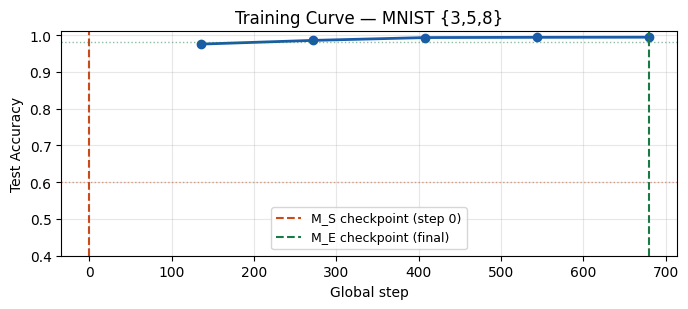


M_S (selected step 0): test acc = 37.3%
M_S (re-measured acc): 37.3%  (target: ~60%)
M_E (final):    test acc = 99.4%  (target: ~98%)


In [4]:
def accuracy(model, loader, device):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits, _ = model(x)
            correct += (logits.argmax(1) == y).sum().item()
            total   += len(y)
    return correct / total


def train(embed_dim=EMBED_DIM, n_epochs=5, device=DEVICE, seed=SEED,
          target_ms_acc: float = 0.95, eval_interval: int = 50):
    """
    Train SmallCNN and return two checkpoints:
        - M_S ('strong'): dynamically found, with test accuracy <= target_ms_acc
        - M_E ('expert'): final checkpoint at end of training

    Args:
        target_ms_acc: The target accuracy for the M_S checkpoint. The function will
                       find the highest accuracy <= this value among periodic evaluations.
        eval_interval: How often (in training steps) to evaluate test accuracy
                       for dynamic M_S checkpoint selection.

    Returns:
        model_S_state: checkpoint state_dict chosen for M_S
        model_E_state: final model state_dict
        history:       list of (global_step, test_acc) tuples (sampled each epoch)
    """
    torch.manual_seed(seed)
    model     = SmallCNN(embed_dim=embed_dim, n_classes=N_CLASSES).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-2)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=1e-2,
        steps_per_epoch=len(train_loader),
        epochs=n_epochs,
        pct_start=0.3,
    )
    criterion = nn.CrossEntropyLoss()

    history = []  # Stores (epoch_end_global_step, epoch_end_test_acc) for plotting

    all_periodic_evals = [] # Stores (global_step, test_acc, model_state_dict) for M_S selection
    global_step = 0

    # Store initial state at global_step 0 before training starts
    initial_acc = accuracy(model, test_loader, device)
    all_periodic_evals.append((0, initial_acc, {k: v.clone() for k, v in model.state_dict().items()}))

    for epoch in range(1, n_epochs + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits, _ = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            scheduler.step()
            global_step += 1

            # Periodically evaluate accuracy and save state for M_S selection
            if global_step % eval_interval == 0:
                current_test_acc = accuracy(model, test_loader, device)
                all_periodic_evals.append((global_step, current_test_acc, {k: v.clone() for k, v in model.state_dict().items()}))

        # Evaluate and save state at epoch end (for history plot)
        epoch_end_test_acc = accuracy(model, test_loader, device)
        history.append((global_step, epoch_end_test_acc))
        print(f"  Epoch {epoch}/{n_epochs}  (step {global_step})  test={epoch_end_test_acc:.1%}")

        # Ensure epoch end state is also considered for M_S if it wasn't picked by eval_interval
        # if global_step % eval_interval != 0: # This check is not entirely robust if an eval happened just before epoch end.
        # Instead, we just add it, duplicates will be handled by selection logic.
        all_periodic_evals.append((global_step, epoch_end_test_acc, {k: v.clone() for k, v in model.state_dict().items()}))

    # ── Select M_S checkpoint dynamically ─────────────────────────────────────
    model_S_state  = None
    ms_actual_acc  = -1.0
    ms_actual_step = -1

    # Find the M_S checkpoint: highest accuracy <= target_ms_acc
    for step, acc, state in all_periodic_evals:
        if acc <= target_ms_acc and acc > ms_actual_acc:
            ms_actual_acc  = acc
            model_S_state  = state
            ms_actual_step = step

    # If no state met the condition (all were above target_ms_acc), take the earliest one with lowest accuracy.
    if model_S_state is None and len(all_periodic_evals) > 0:
        # Sort by accuracy to find the lowest, then by step to find the earliest if accuracies are tied
        sorted_evals = sorted(all_periodic_evals, key=lambda x: (x[1], x[0]))
        model_S_state  = sorted_evals[0][2]
        ms_actual_acc  = sorted_evals[0][1]
        ms_actual_step = sorted_evals[0][0]
        print(f"  Warning: No M_S checkpoint found <= {target_ms_acc:.1%}. Selected earliest checkpoint with lowest accuracy ({ms_actual_acc:.1%}).")
    elif model_S_state is None:
        raise RuntimeError("Failed to find M_S checkpoint. No evaluations were recorded.")

    print(f"  ★ M_S checkpoint selected at global step {ms_actual_step} (test acc = {ms_actual_acc:.1%})")

    model_E_state = {k: v.clone() for k, v in model.state_dict().items()}
    return model_S_state, model_E_state, history, ms_actual_step, ms_actual_acc


print("Training SmallCNN (embed_dim=8, 5 epochs, dynamically finding M_S checkpoint around 95%)...")
ms_state, me_state, history, ms_step, ms_acc = train(embed_dim=EMBED_DIM, target_ms_acc=0.60, eval_interval=50)

# ── Training curve ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.2))
steps    = [h[0] for h in history]
accs     = [h[1] for h in history]
ax.plot(steps, accs, "o-", color="#1a5ca8", linewidth=2, markersize=6)
ax.axvline(ms_step,      color="#c94a1a", linestyle="--", linewidth=1.5,
           label=f"M_S checkpoint (step {ms_step})")
ax.axvline(steps[-1],    color="#1a7a45", linestyle="--", linewidth=1.5,
           label="M_E checkpoint (final)")
ax.axhline(0.60, color="#c94a1a", linestyle=":", linewidth=1, alpha=0.5)
ax.axhline(0.98, color="#1a7a45", linestyle=":", linewidth=1, alpha=0.5)
ax.set_xlabel("Global step"); ax.set_ylabel("Test Accuracy")
ax.set_title("Training Curve — MNIST {3,5,8}")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_ylim(0.40, 1.01)
plt.tight_layout()
plt.show()

print(f"\nM_S (selected step {ms_step}): test acc = {ms_acc:.1%}")
# Load and measure properly
_m = SmallCNN(EMBED_DIM, N_CLASSES).to(DEVICE)
_m.load_state_dict(ms_state)
print(f"M_S (re-measured acc): {accuracy(_m, test_loader, DEVICE):.1%}  (target: ~60%)")
_m.load_state_dict(me_state)
print(f"M_E (final):    test acc = {accuracy(_m, test_loader, DEVICE):.1%}  (target: ~98%)")


## 5 · Extract Embeddings

We run all test images through both checkpoints and collect the **embed_dim-dimensional  
embedding vectors**. These are the inputs to RDX.

We also keep the true labels and original images for visualization later.


Extracting test-set embeddings from M_S (strong)...
Extracting test-set embeddings from M_E (expert)...

Test-set embedding matrices:
  A (M_S):  shape=(2876, 8),  mean_norm=0.433
  B (M_E):  shape=(2876, 8),  mean_norm=17.530
  n = 2876 comparison images

Extracting train-set embeddings from M_S (strong)...
Extracting train-set embeddings from M_E (expert)...

Train-set embedding matrices:
  A_train (M_S):  shape=(17403, 8),  mean_norm=0.432
  B_train (M_E):  shape=(17403, 8),  mean_norm=17.443
  n_train = 17403 training images


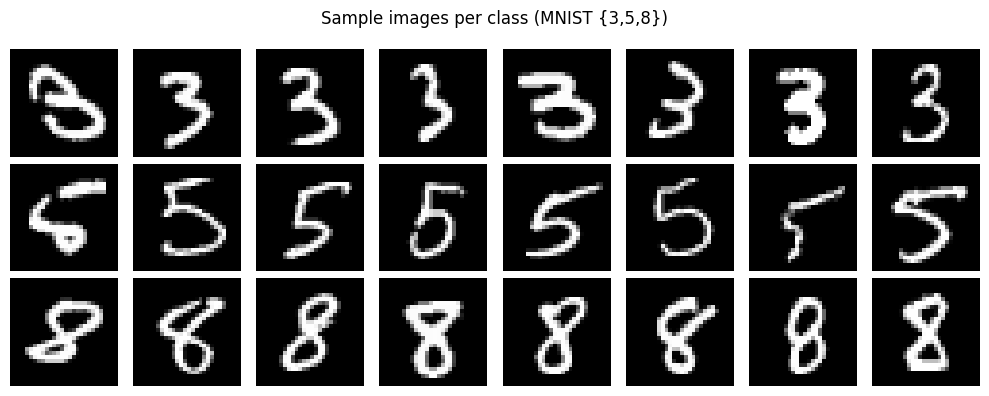

In [5]:
# ── Comparison dataset ────────────────────────────────────────────────────
# Two separate loaders:
#   COMPARE_LOADER      → test set  (fixed order, used for RDX visualisation & BSR)
#   TRAIN_COMPARE_LOADER → train set (fixed order, used for student-training selection)
# Keeping them separate ensures cluster indices always refer to the correct dataset.

COMPARE_LOADER       = DataLoader(test_ds,  batch_size=256, shuffle=False)
TRAIN_COMPARE_LOADER = DataLoader(train_ds, batch_size=256, shuffle=False)

def extract_embeddings(state_dict, loader, device=DEVICE):
    """
    Load a model from state_dict and extract embeddings for all items in loader.

    Returns:
        embeddings: (n, embed_dim) float32 numpy array
        labels:     (n,) int numpy array
        images:     (n, 1, 28, 28) float32 numpy array (for visualization)
    """
    model = SmallCNN(embed_dim=EMBED_DIM, n_classes=N_CLASSES).to(device)
    model.load_state_dict(state_dict)
    model.eval()

    all_emb, all_lbl, all_img = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            _, emb = model(x)
            all_emb.append(emb.cpu().float())
            all_lbl.append(y if isinstance(y, torch.Tensor) else torch.tensor(y))
            all_img.append(x.cpu())

    embeddings = torch.cat(all_emb).numpy()   # (n, embed_dim)
    labels     = torch.cat(all_lbl).numpy()   # (n,)
    images     = torch.cat(all_img).numpy()   # (n, 1, 28, 28)
    return embeddings, labels, images


# ── Test-set embeddings (for visualisation & BSR) ────────────────────────
print("Extracting test-set embeddings from M_S (strong)...")
A, labels, images = extract_embeddings(ms_state, COMPARE_LOADER)

print("Extracting test-set embeddings from M_E (expert)...")
B, _, _           = extract_embeddings(me_state, COMPARE_LOADER)

n = len(A)
print(f"\nTest-set embedding matrices:")
print(f"  A (M_S):  shape={A.shape},  mean_norm={np.linalg.norm(A, axis=1).mean():.3f}")
print(f"  B (M_E):  shape={B.shape},  mean_norm={np.linalg.norm(B, axis=1).mean():.3f}")
print(f"  n = {n} comparison images")

# ── Train-set embeddings (for student-training sample selection) ──────────
print("\nExtracting train-set embeddings from M_S (strong)...")
A_train, labels_train, _ = extract_embeddings(ms_state, TRAIN_COMPARE_LOADER)

print("Extracting train-set embeddings from M_E (expert)...")
B_train, _, _             = extract_embeddings(me_state, TRAIN_COMPARE_LOADER)

n_train = len(A_train)
print(f"\nTrain-set embedding matrices:")
print(f"  A_train (M_S):  shape={A_train.shape},  mean_norm={np.linalg.norm(A_train, axis=1).mean():.3f}")
print(f"  B_train (M_E):  shape={B_train.shape},  mean_norm={np.linalg.norm(B_train, axis=1).mean():.3f}")
print(f"  n_train = {n_train} training images")

# Show a few sample images per class
fig, axes = plt.subplots(3, 8, figsize=(10, 4))
digit_names = {i: str(d) for i, d in enumerate(DIGIT_CLASSES)}
for cls_idx in range(N_CLASSES):
    cls_images = images[labels == cls_idx]
    for j in range(8):
        ax = axes[cls_idx, j]
        ax.imshow(cls_images[j, 0], cmap="gray", interpolation="nearest")
        ax.axis("off")
    axes[cls_idx, 0].set_ylabel(f'digit {digit_names[cls_idx]}', fontsize=10)
fig.suptitle("Sample images per class (MNIST {3,5,8})", fontsize=12)
plt.tight_layout()
plt.show()

## 6 · The RDX Pipeline (using the official RDX repository)

We use the official RDX codebase (`RDX/src/rdx.py`) instead of custom implementations.

| Step | Custom function (replaced) | RDX repo function used |
|------|---------------------------|------------------------|
| 6.1 Rank-based distances | `compute_neighborhood_distances` | `RDXRepo.construct_graph` (`r0_dm`, `r1_dm`) |
| 6.2 Difference matrices | `locally_biased_difference` | `RDXRepo.construct_graph` (`diff_01`, `diff_10`) |
| 6.3 Affinity matrices | `build_affinity_matrix` | `RDXRepo.construct_graph` (`am_01`, `am_10`) |
| 6.4 Spectral clustering | `spectral_cluster` | `RDXRepo.cluster_graph` |
| 6.5 KNA sampling | `kna_sample` | *(kept — no repo equivalent)* |
| 6.7 BSR metric | `binary_success_rate` | *(kept — no repo equivalent)* |

Steps 6.1–6.3 are collapsed into a **single** `RDXRepo.construct_graph` call.

### 6.1–6.3 — Distances, Differences, and Affinity (via `RDXRepo.construct_graph`)


In [6]:
# ── RDX graph construction (replaces custom compute_neighborhood_distances) ─
# RDXRepo.construct_graph computes rank-based distance matrices (r0_dm, r1_dm),
# locally-biased difference matrices (diff_01=D_A−D_B, diff_10=D_B−D_A), and
# affinity matrices (am_01, am_10) all in a single call.
# This replaces the separate compute_neighborhood_distances, locally_biased_difference,
# and build_affinity_matrix functions from the custom implementation.

GAMMA = 0.05   # paper sweeps 0.05 or 0.1; MNIST uses 0.05 here (passed directly to RDX)
BETA  = 5.0    # paper uses β=5 for all experiments

_rdx_params = {
    'sim_function': 'neighborhood',
    'guidance':     None,
    'beta':         BETA,
    'gamma':        GAMMA,          # passed explicitly; bypasses the gamma_scale heuristic
    'diff_function': 'locally_biased',
}

print("Computing RDX graph via RDXRepo.construct_graph (distances + differences + affinities)...")
_graph_dict = RDXRepo.construct_graph(A, B, _rdx_params)

# ── Extract rank-based distance matrices ──────────────────────────────────
# r0_dm / r1_dm: rank of each point j from point i's perspective (0 = self)
# These correspond to the D_bar_A / D_bar_B of the custom implementation.
D_bar_A = _graph_dict['r0_dm'].numpy().astype(np.float32)   # (n, n) ranks for M_S
D_bar_B = _graph_dict['r1_dm'].numpy().astype(np.float32)   # (n, n) ranks for M_E

print(f"\nD_bar_A: shape={D_bar_A.shape}, dtype={D_bar_A.dtype}")
print(f"  min={D_bar_A.min():.0f}  max={D_bar_A.max():.0f}  (expected 0 and {n-1})")
print(f"  diagonal (self-distances, should all be 0): {np.diag(D_bar_A).sum():.0f}")

Computing RDX graph via RDXRepo.construct_graph (distances + differences + affinities)...
Beta: 5.0, Gamma: 0.05

D_bar_A: shape=(2876, 2876), dtype=float32
  min=0  max=2875  (expected 0 and 2875)
  diagonal (self-distances, should all be 0): 0


### 6.2 — Locally-Biased Difference Matrix (extracted from `_graph_dict`)

`_graph_dict['diff_01']` = `tanh(γ · (D_A − D_B) / (min(D_A, D_B) + 1))`  
→ negative entries: items closer in A than B → **unique to M_S**

`_graph_dict['diff_10']` = `tanh(γ · (D_B − D_A) / (min(D_A, D_B) + 1))`  
→ negative entries: items closer in B than A → **unique to M_E**


Extracting difference matrices from RDX graph dict (γ=0.05)...
0.04279895
-0.04279895
G_AB: shape=(2876, 2876)  range=[-1.000, 1.000]


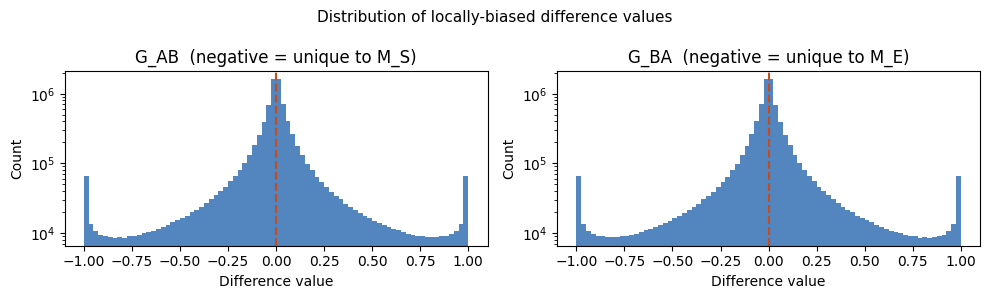


Negative entries = pairs closer in the first model → what we cluster.


In [16]:
# ── Extract difference matrices from the RDX graph dict ───────────────────
# In RDXRepo.construct_graph with r0=A, r1=B:
#   diff_01 = tanh(γ · (r0_dm − r1_dm) / denom) = tanh(γ · (D_A − D_B) / denom)
#             → captures things CLOSER in A than in B  → "unique to M_S"  (≡ G_AB)
#   diff_10 = tanh(γ · (r1_dm − r0_dm) / denom) = tanh(γ · (D_B − D_A) / denom)
#             → captures things CLOSER in B than in A  → "unique to M_E"  (≡ G_BA)
# This replaces the custom locally_biased_difference function.

print(f"Extracting difference matrices from RDX graph dict (γ={GAMMA})...")
G_AB = _graph_dict['diff_01'].numpy().astype(np.float32)   # unique to A (M_S)
G_BA = _graph_dict['diff_10'].numpy().astype(np.float32)   # unique to B (M_E)

print(G_AB[0, 1])
print(G_BA[0, 1])
print(f"G_AB: shape={G_AB.shape}  range=[{G_AB.min():.3f}, {G_AB.max():.3f}]")

# Visualise the distribution of difference values
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, G, title in zip(axes,
                         [G_AB, G_BA],
                         ["G_AB  (negative = unique to M_S)",
                          "G_BA  (negative = unique to M_E)"]):
    ax.hist(G[G != 0].ravel(), bins=80, color="#1a5ca8", alpha=0.75)
    ax.axvline(0, color="#c94a1a", linewidth=1.5, linestyle="--")
    ax.set_xlabel("Difference value"); ax.set_ylabel("Count")
    ax.set_title(title); ax.set_yscale("log")
fig.suptitle("Distribution of locally-biased difference values", fontsize=11)
plt.tight_layout(); plt.show()
print("\nNegative entries = pairs closer in the first model → what we cluster.")

### 6.3 — Affinity Matrix (extracted and symmetrized from `_graph_dict`)

`_graph_dict['am_01']` = `exp(−β · diff_01)` → high affinity for M_S-unique structure  
`_graph_dict['am_10']` = `exp(−β · diff_10)` → high affinity for M_E-unique structure  

We symmetrize `(am + am.T) / 2` to produce the final affinity matrices `F_AB` and `F_BA`.


Extracting & symmetrizing affinity matrices from RDX graph dict (β=5.0)...
F_AB: shape=(2876, 2876)  range=[0.000, 148.413]


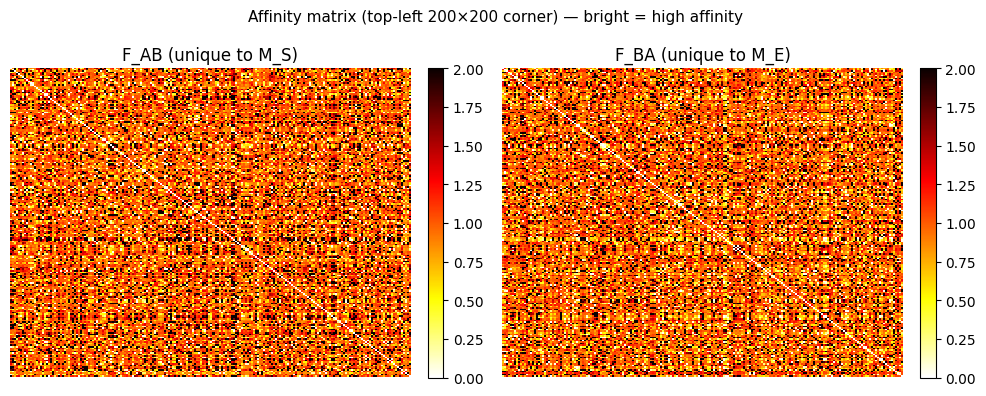

In [8]:
# ── Extract affinity matrices from the RDX graph dict ─────────────────────
# In RDXRepo.construct_graph with r0=A, r1=B:
#   am_01 = exp(−β · diff_01)   → high affinity where A groups things closer  (≡ F_AB)
#   am_10 = exp(−β · diff_10)   → high affinity where B groups things closer  (≡ F_BA)
# We symmetrize to match the custom build_affinity_matrix behavior.
# (RDXRepo.cluster_graph also symmetrizes internally; we do it here so that
#  the downstream kna_sample and binary_success_rate functions receive symmetric F.)
# This replaces the custom build_affinity_matrix function.

print(f"Extracting & symmetrizing affinity matrices from RDX graph dict (β={BETA})...")
_am_01 = _graph_dict['am_01']
_am_10 = _graph_dict['am_10']

F_AB_t = ((_am_01 + _am_01.T) / 2)
F_BA_t = ((_am_10 + _am_10.T) / 2)
F_AB_t.fill_diagonal_(0.0)
F_BA_t.fill_diagonal_(0.0)

F_AB = F_AB_t.numpy().astype(np.float32)   # symmetrized affinity: unique to M_S
F_BA = F_BA_t.numpy().astype(np.float32)   # symmetrized affinity: unique to M_E

print(f"F_AB: shape={F_AB.shape}  range=[{F_AB.min():.3f}, {F_AB.max():.3f}]")

# Visualize a 200×200 corner of the affinity matrix
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, F, title in zip(axes, [F_AB, F_BA],
                          ["F_AB (unique to M_S)", "F_BA (unique to M_E)"]):
    im = ax.imshow(F[:200, :200], cmap="hot_r", aspect="auto",
                   interpolation="nearest", vmin=0, vmax=2)
    ax.set_title(title); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Affinity matrix (top-left 200×200 corner) — bright = high affinity",
             fontsize=11)
plt.tight_layout(); plt.show()

### 6.4 — Spectral Clustering (via `RDXRepo.cluster_graph`)

`RDXRepo.cluster_graph` requests `m+1` clusters (`add_null_cluster=True`),  
then `post_process` re-labels them in ascending affinity order so that  
cluster label **0** is always the lowest-affinity (shared/boring) cluster.  
We discard label 0, keeping the `m` most semantically distinct clusters.


In [9]:
# ── Spectral clustering via RDXRepo.cluster_graph ─────────────────────────
# RDXRepo.cluster_graph processes both am_01 (F_AB) and am_10 (F_BA) in a single
# call, runs SpectralClustering with n_clusters+1 (add_null_cluster=True) and
# reorders clusters by ascending within-cluster affinity via post_process so that
# cluster label 0 = lowest-affinity (shared/boring) cluster.
# We then discard label 0 to match the custom spectral_cluster behavior.
# This replaces the custom spectral_cluster function.

M = 8   # number of explanation grids requested (paper uses 3 for MNIST; §C.5)

_cluster_params = {
    'clustering_method': 'spectral',
    'n_clusters':        M,
    'add_null_cluster':  True,   # requests M+1 clusters; cluster 0 = lowest affinity
}

print(f"Spectral clustering via RDXRepo.cluster_graph (m={M})...")
_cluster_dict = RDXRepo.cluster_graph(_graph_dict, _cluster_params)

def _labels_to_cluster_list(cluster_dict_entry, affinity_mat_np, n_pts):
    """Convert RDX cluster_labels output → (list-of-index-arrays, list-of-affinities).
    
    RDXRepo.post_process sorts clusters by ascending mean affinity, assigning label 0
    to the lowest-affinity (null/garbage) cluster.  We skip label 0 here.
    """
    labels    = cluster_dict_entry['cluster_labels']
    unique_cl = sorted(np.unique(labels))
    clusters, affinities = [], []
    for k in unique_cl:
        if k == 0:                        # null cluster – discard
            _idx = np.where(labels == k)[0]
            _sub = affinity_mat_np[np.ix_(_idx, _idx)]
            print(f"  Discarding null cluster (label 0): "
                  f"mean affinity={float(_sub.mean()):.4f}, size={len(_idx)}")
            continue
        idx = np.where(labels == k)[0]
        sub = affinity_mat_np[np.ix_(idx, idx)]
        clusters.append(idx)
        affinities.append(float(sub.mean()))
    return clusters, affinities

clusters_AB, affs_AB = _labels_to_cluster_list(_cluster_dict['am_01'], F_AB, n)
clusters_BA, affs_BA = _labels_to_cluster_list(_cluster_dict['am_10'], F_BA, n)

print(f"\nClusters for M_S (sizes): {[len(c) for c in clusters_AB]}")
print(f"Clusters for M_E (sizes): {[len(c) for c in clusters_BA]}")

Spectral clustering via RDXRepo.cluster_graph (m=8)...


[5 5 6 ... 2 1 5]
0 tensor(11.7908)
1 tensor(15.0553)
2 tensor(15.2474)
3 tensor(19.7347)
4 tensor(20.7453)
5 tensor(23.5300)
6 tensor(23.6265)
7 tensor(26.6153)
8 tensor(30.8194)
[0 4 4 ... 1 4 7]
0 tensor(11.6235)
1 tensor(11.6849)
2 tensor(16.0041)
3 tensor(16.1868)
4 tensor(16.7571)
5 tensor(17.0906)
6 tensor(17.8854)
7 tensor(18.4379)
8 tensor(21.1291)
  Discarding null cluster (label 0): mean affinity=11.6212, size=439
  Discarding null cluster (label 0): mean affinity=11.7885, size=442

Clusters for M_S (sizes): [373, 296, 353, 302, 309, 274, 261, 269]
Clusters for M_E (sizes): [313, 441, 335, 329, 301, 253, 256, 206]


### 6.5 — K-Neighborhood Affinity (KNA) Sampling

Each spectral cluster may contain hundreds of images. KNA picks the  
most representative 9-image grid: the image with the highest total  
affinity to its 8 nearest neighbors within the cluster.


In [10]:
def kna_sample(cluster_indices: np.ndarray,
               F: np.ndarray,
               k: int = 8) -> np.ndarray:
    """
    K-Neighborhood Affinity sampling.

    For each image i in the cluster:
        KNA(i) = sum of F[i, j] for i's k nearest neighbors j in the cluster

    Returns the image with highest KNA + its k neighbors → k+1 image indices.
    These form the 3×3 explanation grid.

    Args:
        k: neighborhood size; grid contains k+1 images. Paper uses k=8 (3×3 grids).
    """
    idx   = cluster_indices
    F_sub = F[np.ix_(idx, idx)]           # (r, r) sub-matrix for this cluster
    r     = len(idx)
    k     = min(k, r - 1)                 # guard for tiny clusters

    kna_scores = []
    neighbors  = []
    for i in range(r):
        row         = F_sub[i].copy()
        row[i]      = -np.inf             # exclude self
        topk_local  = np.argpartition(row, -k)[-k:]
        topk_local  = topk_local[np.argsort(row[topk_local])[::-1]]
        kna_scores.append(row[topk_local].sum())
        neighbors.append(topk_local)

    best       = int(np.argmax(kna_scores))
    grid_local = np.array([best] + neighbors[best].tolist())
    return idx[grid_local]                # back to global image indices


KNA_K = 8   # 8 neighbors + 1 anchor = 9 images → 3×3 grid

explanation_grids_AB = [kna_sample(c, F_AB, k=KNA_K) for c in clusters_AB]
explanation_grids_BA = [kna_sample(c, F_BA, k=KNA_K) for c in clusters_BA]

print(f"Sampled {len(explanation_grids_AB)} explanation grids for M_S concepts")
print(f"Sampled {len(explanation_grids_BA)} explanation grids for M_E concepts")
print(f"Each grid contains {KNA_K+1} images (3×3 layout)")

Sampled 8 explanation grids for M_S concepts
Sampled 8 explanation grids for M_E concepts
Each grid contains 9 images (3×3 layout)


## 7 · Visualize Explanation Grids

This is the main result. Each 3×3 grid shows a concept that is  
**unique to one model** — images that model groups tightly together  
but the other model does not.

Compare to Fig. 2(B) in the paper.


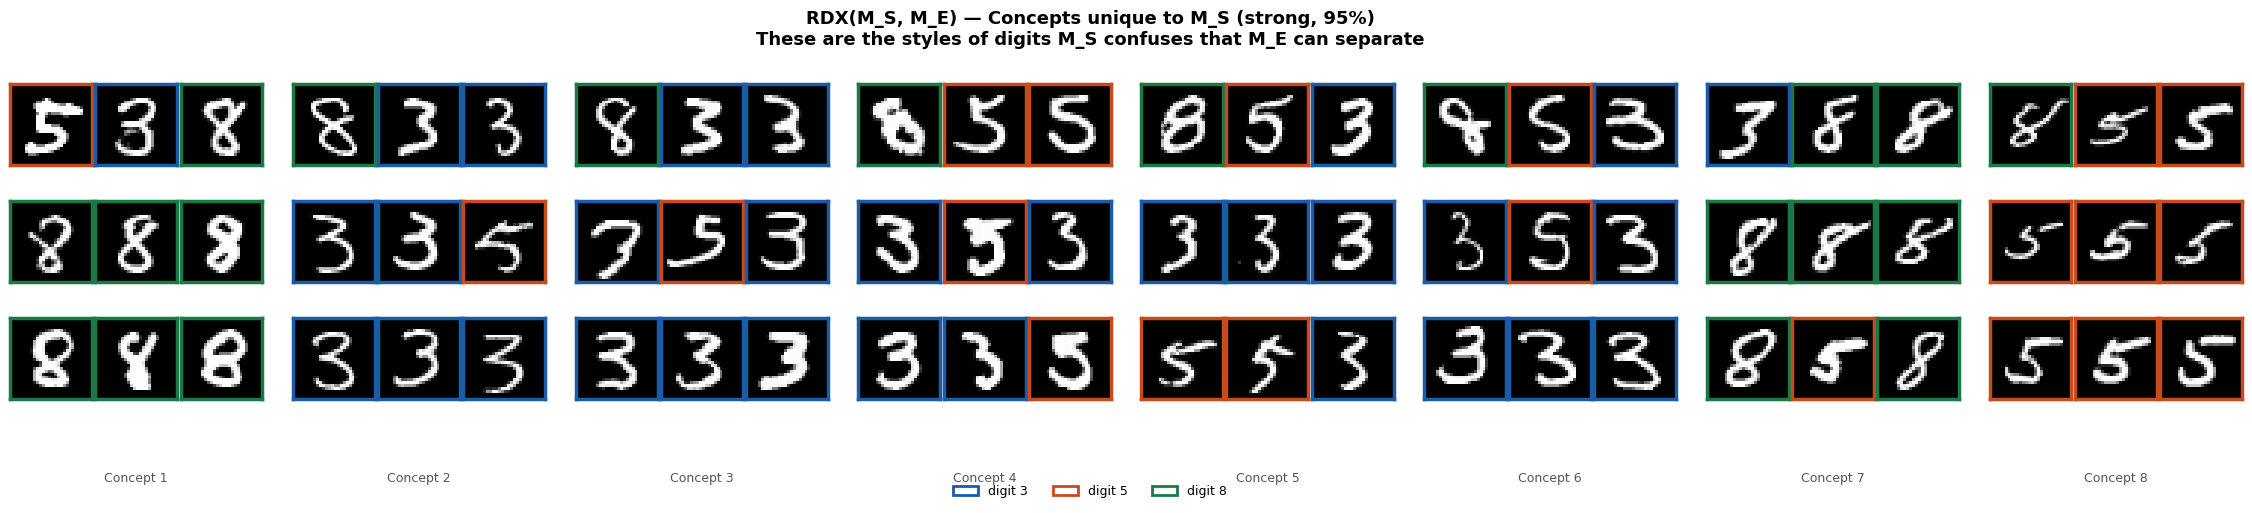

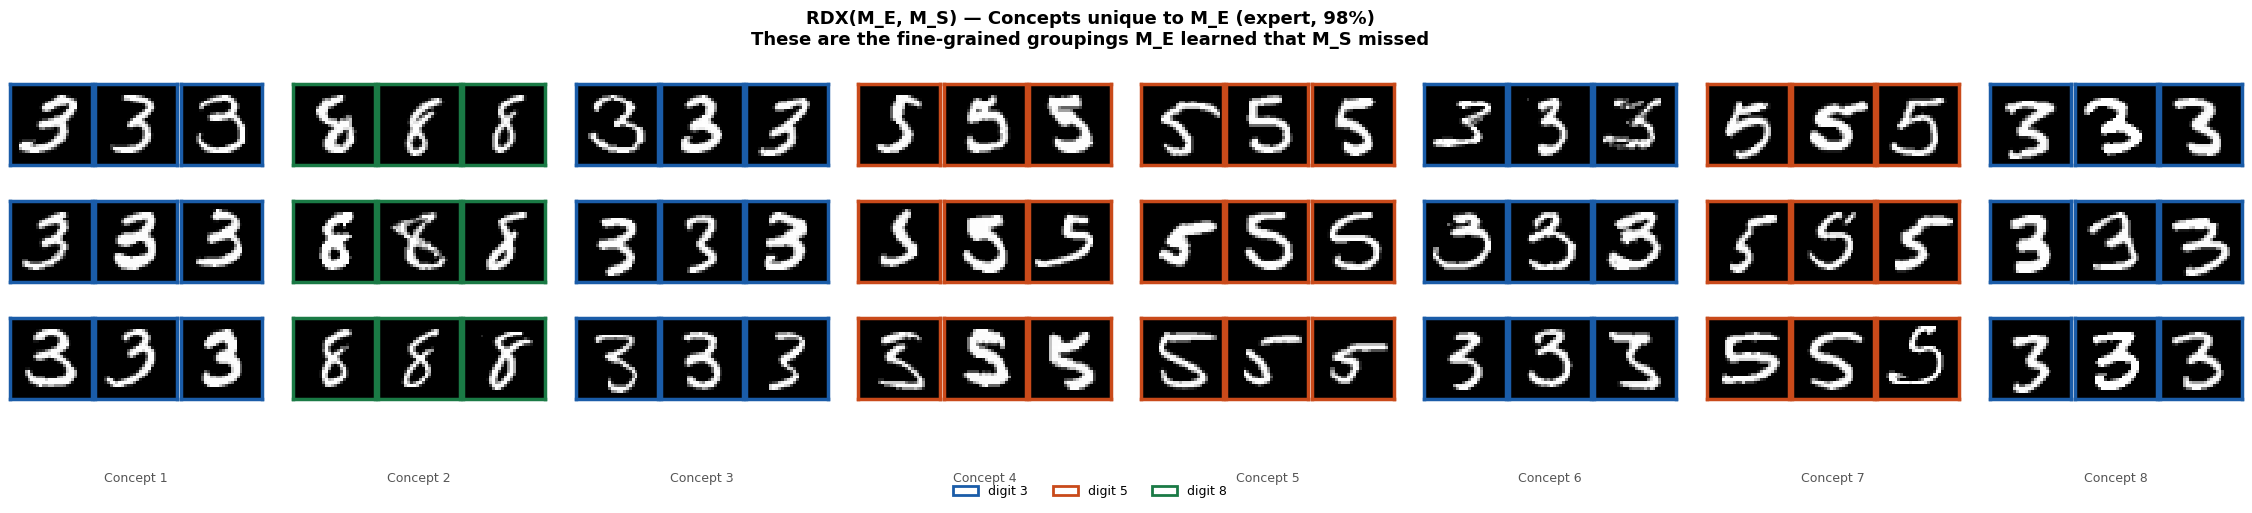

In [11]:
def denormalize(img_array):
    """Undo MNIST normalization for display."""
    mean, std = 0.1307, 0.3081
    return np.clip(img_array * std + mean, 0, 1)


def plot_explanation_grids(grids, images, labels, title,
                           digit_classes=DIGIT_CLASSES,
                           grid_cols=3):
    """
    Plot a row of 3×3 explanation grids side by side.

    Args:
        grids:   list of arrays of image indices (one per concept)
        images:  (n, 1, 28, 28) image array
        labels:  (n,) label array
        title:   figure suptitle
    """
    n_concepts = len(grids)
    grid_size  = int(round(len(grids[0]) ** 0.5))   # should be 3 for 9 images

    fig = plt.figure(figsize=(n_concepts * 3.6, 4.5))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)

    # Color borders by digit class (matching Fig. 2 style)
    class_colors = ["#1a5ca8", "#c94a1a", "#1a7a45"]   # blue=3, red=5, green=8

    outer = gridspec.GridSpec(1, n_concepts, figure=fig,
                               wspace=0.12, hspace=0.05)

    for concept_i, grid_idx in enumerate(grids):
        inner = gridspec.GridSpecFromSubplotSpec(
            grid_size, grid_size,
            subplot_spec=outer[concept_i],
            wspace=0.04, hspace=0.04
        )

        for pos, img_idx in enumerate(grid_idx[:grid_size**2]):
            row_pos = pos // grid_size
            col_pos = pos  % grid_size
            ax = fig.add_subplot(inner[row_pos, col_pos])

            img_data = denormalize(images[img_idx, 0])
            lbl      = labels[img_idx]

            ax.imshow(img_data, cmap="gray", interpolation="nearest")

            # Colored border indicates digit class
            color = class_colors[lbl]
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2.5)
            ax.tick_params(left=False, bottom=False,
                           labelleft=False, labelbottom=False)

        # Concept label
        mean_digit = digit_classes[int(np.bincount(labels[grid_idx]).argmax())]
        fig.text(
            outer[concept_i].get_position(fig).x0 +
            outer[concept_i].get_position(fig).width / 2,
            -0.04,
            f"Concept {concept_i + 1}",
            ha="center", fontsize=9, color="#555"
        )

    # Legend
    legend_elements = [
        plt.Rectangle((0,0),1,1, fc="white", ec=class_colors[i], linewidth=2,
                       label=f"digit {digit_classes[i]}")
        for i in range(len(digit_classes))
    ]
    fig.legend(handles=legend_elements, loc="lower center",
               ncol=3, fontsize=9, frameon=False,
               bbox_to_anchor=(0.5, -0.10))

    plt.tight_layout()
    plt.show()


# ── Plot M_S concepts (what M_S groups that M_E does not) ──────────────────
plot_explanation_grids(
    explanation_grids_AB, images, labels,
    title="""RDX(M_S, M_E) — Concepts unique to M_S (strong, 95%)
These are the styles of digits M_S confuses that M_E can separate"""
)

# ── Plot M_E concepts (what M_E groups that M_S does not) ──────────────────
plot_explanation_grids(
    explanation_grids_BA, images, labels,
    title="""RDX(M_E, M_S) — Concepts unique to M_E (expert, 98%)
These are the fine-grained groupings M_E learned that M_S missed"""
)


## 8 · Evaluate — Binary Success Rate (BSR)

BSR measures what fraction of image pairs in each explanation grid  
are actually closer in the source model than the other.

**Interpretation:**

- BSR = 1.0 → perfect (all pairs are uniquely close in the right model)
- BSR = 0.5 → random baseline
- Paper reports RDX achieves BSR ≈ 0.83–0.91 on MNIST comparisons


  Binary Success Rate (BSR) Results
  BSR(E^A)  [M_S concepts] = 0.983
  BSR(E^B)  [M_E concepts] = 0.986

  Paper reports RDX achieves:
  BSR ≈ 0.83–0.91 on MNIST comparisons (Table A3)

  Random baseline = 0.50


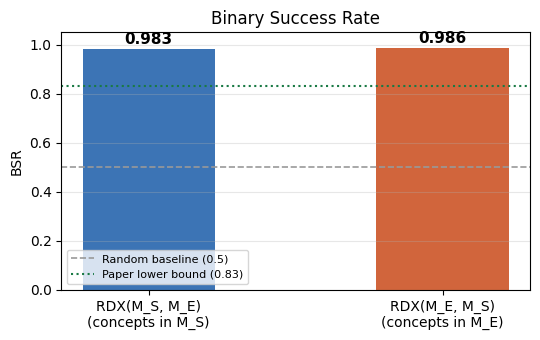

In [12]:
def binary_success_rate(grids: list,
                        D_bar_source: np.ndarray,
                        D_bar_other:  np.ndarray) -> float:
    """
    BSR(E^A): fraction of pairs (i,j) in explanation grids where
    D_bar_source[i,j] < D_bar_other[i,j].

    A high BSR confirms the grids actually capture structure
    unique to the source model.
    """
    successes = total = 0
    for grid in grids:
        r = len(grid)
        for ii in range(r):
            for jj in range(ii + 1, r):
                i, j = grid[ii], grid[jj]
                if D_bar_source[i, j] < D_bar_other[i, j]:
                    successes += 1
                total += 1
    return successes / total if total > 0 else 0.0


bsr_S = binary_success_rate(explanation_grids_AB, D_bar_A, D_bar_B)
bsr_E = binary_success_rate(explanation_grids_BA, D_bar_B, D_bar_A)

print("=" * 50)
print("  Binary Success Rate (BSR) Results")
print("=" * 50)
print(f"  BSR(E^A)  [M_S concepts] = {bsr_S:.3f}")
print(f"  BSR(E^B)  [M_E concepts] = {bsr_E:.3f}")
print()
print("  Paper reports RDX achieves:")
print("  BSR ≈ 0.83–0.91 on MNIST comparisons (Table A3)")
print()
print("  Random baseline = 0.50")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(5.5, 3.5))
bars = ax.bar(
    ["""RDX(M_S, M_E)
(concepts in M_S)""", """RDX(M_E, M_S)
(concepts in M_E)"""],
    [bsr_S, bsr_E],
    color=["#1a5ca8", "#c94a1a"], width=0.45, alpha=0.85
)
ax.axhline(0.5,  color="#999", linestyle="--", linewidth=1.2, label="Random baseline (0.5)")
ax.axhline(0.83, color="#1a7a45", linestyle=":",  linewidth=1.5, label="Paper lower bound (0.83)")
ax.set_ylim(0, 1.05)
ax.set_ylabel("BSR")
ax.set_title("Binary Success Rate")
ax.legend(fontsize=8)
for bar, val in zip(bars, [bsr_S, bsr_E]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 9 · Clean Reusable Class

All the above wrapped into a single `RDX` class for easy reuse  
on other datasets / model pairs.


In [13]:
from dataclasses import dataclass, field

@dataclass
class RDXConfig:
    gamma:        float = 0.1   # difference function saturation
    beta:         float = 5.0   # affinity sharpness
    n_concepts:   int   = 5     # number of explanation grids
    kna_k:        int   = 8     # neighbors per grid (grid = k+1 images)
    random_state: int   = 42


class RDXWrapper:
    """
    Thin wrapper around RDXRepo (the official RDX repository class) that exposes
    the same .fit(A, B) interface as the previous custom implementation.

    Internally delegates to:
      - RDXRepo.construct_graph  → rank distances + difference + affinity matrices
      - RDXRepo.cluster_graph    → spectral clustering (m+1 clusters, null cluster dropped)
      - kna_sample               → K-Neighborhood Affinity sampling (no RDX-repo equivalent)
      - binary_success_rate      → BSR metric (no RDX-repo equivalent)
    """
    def __init__(self, config: RDXConfig = None):
        self.cfg = config or RDXConfig()

    def fit(self, A: np.ndarray, B: np.ndarray):
        cfg = self.cfg

        rdx_params = {
            'sim_function':  'neighborhood',
            'guidance':      None,
            'beta':          cfg.beta,
            'gamma':         cfg.gamma,
            'diff_function': 'locally_biased',
        }
        cluster_params = {
            'clustering_method': 'spectral',
            'n_clusters':        cfg.n_concepts,
            'add_null_cluster':  True,   # requests n+1 clusters; cluster 0 = lowest affinity
        }

        # ── Step 1-3: construct graph (distances + differences + affinities) ──
        print("[1/3] RDXRepo.construct_graph (distances + differences + affinities)...")
        gd = RDXRepo.construct_graph(A, B, rdx_params)

        D_A = gd['r0_dm'].numpy().astype(np.float32)
        D_B = gd['r1_dm'].numpy().astype(np.float32)

        am01 = gd['am_01'];  am01_sym = (am01 + am01.T) / 2;  am01_sym.fill_diagonal_(0.0)
        am10 = gd['am_10'];  am10_sym = (am10 + am10.T) / 2;  am10_sym.fill_diagonal_(0.0)
        F_AB = am01_sym.numpy().astype(np.float32)   # A-unique affinity
        F_BA = am10_sym.numpy().astype(np.float32)   # B-unique affinity

        # ── Step 4: cluster graph ─────────────────────────────────────────────
        print("[2/3] RDXRepo.cluster_graph (spectral clustering)...")
        cd = RDXRepo.cluster_graph(gd, cluster_params)

        clusters_AB, _ = _labels_to_cluster_list(cd['am_01'], F_AB, len(A))
        clusters_BA, _ = _labels_to_cluster_list(cd['am_10'], F_BA, len(B))

        # ── Step 5: KNA sampling & BSR (no RDXRepo equivalent) ───────────────
        print("[3/3] KNA sampling + BSR...")
        grids_A = [kna_sample(c, F_AB, k=cfg.kna_k) for c in clusters_AB]
        grids_B = [kna_sample(c, F_BA, k=cfg.kna_k) for c in clusters_BA]

        bsr_A = binary_success_rate(grids_A, D_A, D_B)
        bsr_B = binary_success_rate(grids_B, D_B, D_A)
        print(f"Done.  BSR(A)={bsr_A:.3f}  BSR(B)={bsr_B:.3f}")

        return type("RDXResult", (), dict(
            grids_A=grids_A, grids_B=grids_B,
            bsr_A=bsr_A,     bsr_B=bsr_B,
            D_bar_A=D_A,     D_bar_B=D_B,
            F_AB=F_AB,       F_BA=F_BA,
        ))()


# ── Demo: run the whole pipeline via RDXWrapper ────────────────────────────
print("Running full RDX pipeline via RDXWrapper (backed by RDXRepo)...")
rdx    = RDXWrapper(RDXConfig(gamma=0.1, beta=5.0, n_concepts=3, kna_k=8))
result = rdx.fit(A, B)

print(f"\ngrids_A[0] (first M_S concept):  image indices = {result.grids_A[0]}")
print(f"BSR(A) = {result.bsr_A:.3f} | BSR(B) = {result.bsr_B:.3f}")

Running full RDX pipeline via RDXWrapper (backed by RDXRepo)...
[1/3] RDXRepo.construct_graph (distances + differences + affinities)...
Beta: 5.0, Gamma: 0.1
[2/3] RDXRepo.cluster_graph (spectral clustering)...
[1 1 2 ... 0 3 1]
0 tensor(14.0094)
1 tensor(18.3666)
2 tensor(22.1766)
3 tensor(29.1364)
[1 1 1 ... 0 1 3]
0 tensor(12.7760)
1 tensor(16.2027)
2 tensor(17.0012)
3 tensor(18.2505)
  Discarding null cluster (label 0): mean affinity=12.7749, size=888
  Discarding null cluster (label 0): mean affinity=14.0084, size=974
[3/3] KNA sampling + BSR...
Done.  BSR(A)=0.944  BSR(B)=1.000

grids_A[0] (first M_S concept):  image indices = [   1 1189 1738 1743 2253  186 1518 1098  135]
BSR(A) = 0.944 | BSR(B) = 1.000


## Execute Student Training Experiments

### Subtask:

Initialize two new SmallCNN models, both starting from the M_S checkpoint. Train the first student using a DataLoader generated from random sampling and the second using a DataLoader generated from RDX-based sampling. Record their training loss and test accuracy over epochs.


Building train-set RDX pipeline for student-training selection...
  Using 5000-image subsample of train set (full size: 17403) to keep memory manageable.
  [1/3] RDXRepo.construct_graph (train subsample)...
Beta: 5.0, Gamma: 0.05


  [2/3] RDXRepo.cluster_graph (train)...
[2 2 2 ... 1 2 1]
0 tensor(8.0270)
1 tensor(9.9525)
2 tensor(12.8868)
3 tensor(17.0607)
[2 1 0 ... 2 1 3]
0 tensor(7.9623)
1 tensor(9.5396)
2 tensor(9.8517)
3 tensor(10.0552)
  [3/3] Converting cluster labels → index arrays...
  Discarding null cluster (label 0): mean affinity=7.9616, size=1461

Train-set clusters (sizes): [1188, 1224, 1127]
Max cluster index : 17401  (train set size: 17403)  ✓ indices match
Student training budget size: 3480 samples (20% of 17403).

--- Training student with Random Sampling ---
Created random dataloader with 3480 samples.

Training student model on 3480 samples for 10 epochs...
  Epoch 1/10: Train Loss = 1.0461, Test Acc = 62.0%
  Epoch 2/10: Train Loss = 0.8128, Test Acc = 83.9%
  Epoch 3/10: Train Loss = 0.5404, Test Acc = 89.7%
  Epoch 4/10: Train Loss = 0.3650, Test Acc = 92.4%
  Epoch 5/10: Train Loss = 0.2722, Test Acc = 94.2%
  Epoch 6/10: Train Loss = 0.2363, Test Acc = 95.2%
  Epoch 7/10: Train Loss = 

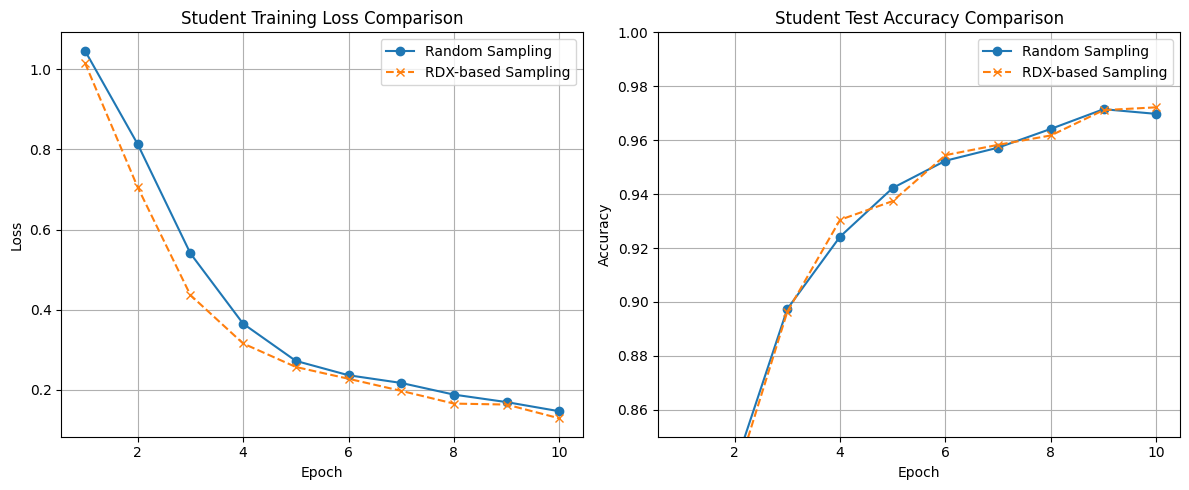


--- Summary of Distillation Experiment Findings ---
Student models were trained on a reduced dataset (20% of original training data).
Budget size: 3480 samples.

Final Training Loss:
  Random Sampling: 0.1465
  RDX-based Sampling: 0.1288

Final Test Accuracy:
  Random Sampling: 96.975%
  RDX-based Sampling: 97.218%

Observations:
  RDX-based sampling achieved a higher final test accuracy (97.218%) compared to random sampling (96.975%).
  RDX-based sampling generally showed lower training loss throughout training.


In [14]:
import torch.nn.functional as F  # Re-import to ensure F refers to torch.nn.functional
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

# ── Build train-set RDX pipeline ─────────────────────────────────────────
# The visualisation / BSR cells above used test-set embeddings (A, B).
# For student-training sample selection we need cluster indices that map into
# train_ds, so we run the full RDX pipeline again on the train-set embeddings
# (A_train, B_train) extracted in cell 5.

print("Building train-set RDX pipeline for student-training selection...")

# The full train set has ~17k images → n×n distance matrix ≈ 1.2 GB (float32).
# We subsample a manageable number; 5 000 images → ~100 MB, still captures
# the concept structure reliably.
RDX_SUBSAMPLE_N = 5000
np.random.seed(SEED)
sub_idx = np.sort(np.random.choice(n_train, size=min(RDX_SUBSAMPLE_N, n_train), replace=False))

A_train_sub = A_train[sub_idx]
B_train_sub = B_train[sub_idx]
print(f"  Using {len(sub_idx)}-image subsample of train set "
      f"(full size: {n_train}) to keep memory manageable.")

# ── Use RDXRepo for the train-set pipeline (mirrors the test-set cells above) ─
_train_rdx_params = {
    'sim_function':  'neighborhood',
    'guidance':      None,
    'beta':          BETA,
    'gamma':         GAMMA,
    'diff_function': 'locally_biased',
}
_train_cluster_params = {
    'clustering_method': 'spectral',
    'n_clusters':        3,
    'add_null_cluster':  True,
}

print("  [1/3] RDXRepo.construct_graph (train subsample)...")
_train_gd = RDXRepo.construct_graph(A_train_sub, B_train_sub, _train_rdx_params)

D_bar_A_train = _train_gd['r0_dm'].numpy().astype(np.float32)
D_bar_B_train = _train_gd['r1_dm'].numpy().astype(np.float32)

_train_am01 = _train_gd['am_01']
_train_am01_sym = (_train_am01 + _train_am01.T) / 2
_train_am01_sym.fill_diagonal_(0.0)
F_AB_train = _train_am01_sym.numpy().astype(np.float32)

print("  [2/3] RDXRepo.cluster_graph (train)...")
_train_cd = RDXRepo.cluster_graph(_train_gd, _train_cluster_params)

print("  [3/3] Converting cluster labels → index arrays...")
clusters_AB_train_local, _ = _labels_to_cluster_list(_train_cd['am_01'], F_AB_train, len(A_train_sub))

# Map local subsample positions → global train_ds indices
clusters_AB_train = [sub_idx[c] for c in clusters_AB_train_local]

print(f"\nTrain-set clusters (sizes): {[len(c) for c in clusters_AB_train]}")
print(f"Max cluster index : {max(max(c) for c in clusters_AB_train)}  "
      f"(train set size: {len(train_ds)})  ✓ indices match")


def train_student(model, dataloader, num_epochs, device, criterion, optimizer, scheduler=None):
    """
    Trains a student model and records training loss and test accuracy per epoch.

    Args:
        model: The SmallCNN model to train.
        dataloader: DataLoader for the training dataset.
        num_epochs: Number of epochs to train for.
        device: The device to train on ('cuda' or 'cpu').
        criterion: The loss function (e.g., nn.CrossEntropyLoss()).
        optimizer: The optimizer (e.g., optim.Adam()).
        scheduler: (Optional) Learning rate scheduler.

    Returns:
        model: The trained SmallCNN model.
        train_losses: List of training losses per epoch.
        test_accuracies: List of test accuracies per epoch.
    """
    model.to(device)

    train_losses = []
    test_accuracies = []

    print(f"\nTraining student model on {len(dataloader.dataset)} samples for {num_epochs} epochs...")

    for epoch in range(1, num_epochs + 1):
        model.train() # Set model to training mode
        running_loss = 0.0

        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits, _ = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            if scheduler:
                scheduler.step()

            running_loss += loss.item() * x.size(0) # Accumulate weighted loss

        # Calculate average epoch loss
        epoch_loss = running_loss / len(dataloader.dataset)
        train_losses.append(epoch_loss)

        # Evaluate test accuracy
        model.eval() # Set model to evaluation mode
        epoch_acc = accuracy(model, test_loader, device) # Assuming test_loader is globally accessible
        test_accuracies.append(epoch_acc)

        print(f"  Epoch {epoch}/{num_epochs}: Train Loss = {epoch_loss:.4f}, Test Acc = {epoch_acc:.1%}")

    print("Student training complete.")
    return model, train_losses, test_accuracies


def get_random_dataloader(full_dataset, budget_size, batch_size):
    """
    Randomly samples `budget_size` unique indices from the full dataset
    and creates a DataLoader for these samples.

    Args:
        full_dataset (torch.utils.data.Dataset): The complete training dataset.
        budget_size (int): The number of samples to select for the DataLoader.
        batch_size (int): The batch size for the DataLoader.

    Returns:
        torch.utils.data.DataLoader: A DataLoader containing randomly selected samples.
    """
    n_samples = len(full_dataset)
    if budget_size > n_samples:
        budget_size = n_samples
        print(f"Warning: budget_size ({budget_size}) is greater than dataset size ({n_samples}). Using full dataset.")

    indices = np.random.choice(n_samples, budget_size, replace=False)
    subset_dataset = Subset(full_dataset, indices)
    dataloader = DataLoader(subset_dataset, batch_size=batch_size, shuffle=True,
                            num_workers=0, pin_memory=False)
    print(f"Created random dataloader with {len(subset_dataset)} samples.")
    return dataloader

def get_rdx_dataloader(full_dataset, budget_size, batch_size, clusters_AB, clusters_BA,
                       F_AB, F_BA, kna_k, index_map=None):
    """
    Selects 'hardest' examples from RDX clusters based on KNA scores
    and creates a DataLoader.

    Args:
        full_dataset  : The complete training dataset (e.g. train_ds).
        budget_size   : Number of samples to select.
        batch_size    : DataLoader batch size.
        clusters_AB   : List of arrays of *local* cluster indices (positions inside F_AB).
        clusters_BA   : Same for the B-side (pass [] if unused).
        F_AB          : Affinity matrix whose rows/cols correspond to cluster indices.
        F_BA          : Affinity matrix for B-side (pass None if unused).
        kna_k         : Number of neighbours for KNA scoring.
        index_map     : Optional 1-D array.  When the clusters come from a subsampled RDX
                        run, pass sub_idx here so that local positions are translated to
                        global full_dataset indices before building the Subset.
                        When None, cluster indices are used directly as dataset indices.

    Returns:
        torch.utils.data.DataLoader: A DataLoader containing RDX-selected samples.
    """
    all_rdx_indices_with_scores = []

    # Process clusters unique to M_S (F_AB)
    for cluster_indices_local in clusters_AB:
        if len(cluster_indices_local) == 0:
            continue
        # Affinity sub-matrix — always indexed in *local* (subsample) space
        F_sub = F_AB[np.ix_(cluster_indices_local, cluster_indices_local)]
        r = len(cluster_indices_local)

        kna_scores = np.zeros(r)
        for i in range(r):
            row = F_sub[i].copy()
            row[i] = -np.inf  # exclude self-affinity

            current_k = min(kna_k, r - 1)
            if current_k > 0:
                topk_local_indices = np.argpartition(row, -current_k)[-current_k:]
                kna_scores[i] = row[topk_local_indices].sum()
            else:
                kna_scores[i] = 0.0

        for i, local_idx in enumerate(cluster_indices_local):
            # Translate to a global full_dataset index
            global_idx = int(index_map[local_idx]) if index_map is not None else int(local_idx)
            all_rdx_indices_with_scores.append((global_idx, kna_scores[i]))

    # Process clusters unique to M_E (F_BA)
    # for cluster_indices_global in clusters_BA:
    #     if len(cluster_indices_global) == 0:
    #         continue
    #     F_sub = F_BA[np.ix_(cluster_indices_global, cluster_indices_global)]
    #     r = len(cluster_indices_global)

    #     kna_scores = np.zeros(r)
    #     for i in range(r):
    #         row = F_sub[i].copy()
    #         row[i] = -np.inf

    #         current_k = min(kna_k, r - 1)
    #         if current_k > 0:
    #             topk_local_indices = np.argpartition(row, -current_k)[-current_k:]
    #             kna_scores[i] = row[topk_local_indices].sum()
    #         else:
    #             kna_scores[i] = 0.0

    #     for i, global_idx in enumerate(cluster_indices_global):
    #         all_rdx_indices_with_scores.append((global_idx, kna_scores[i]))

    # Sort all collected (global_index, KNA_score) pairs by KNA score (descending)
    all_rdx_indices_with_scores.sort(key=lambda x: x[1], reverse=True)

    # Get unique global indices from the sorted list
    unique_rdx_indices = []
    seen_indices = set()
    for idx, _ in all_rdx_indices_with_scores:
        if idx not in seen_indices:
            unique_rdx_indices.append(idx)
            seen_indices.add(idx)

    # Select `budget_size` top unique indices
    if len(unique_rdx_indices) > budget_size:
        selected_indices = unique_rdx_indices[:budget_size]
    else:
        shortfall = budget_size - len(unique_rdx_indices)
        print(f"Warning: RDX found {len(unique_rdx_indices)} unique samples (budget={budget_size}). "
            f"Padding with {shortfall} random samples from outside the RDX pool.")
        all_indices = np.arange(len(full_dataset))
        remaining_indices = np.setdiff1d(all_indices, list(seen_indices))
        pad_indices = np.random.choice(remaining_indices, size=shortfall, replace=False).tolist()
        selected_indices = unique_rdx_indices + pad_indices

    subset_dataset = Subset(full_dataset, selected_indices)
    dataloader = DataLoader(subset_dataset, batch_size=batch_size, shuffle=True,
                            num_workers=0, pin_memory=False)
    print(f"Created RDX-based dataloader with {len(subset_dataset)} samples.")
    return dataloader


# --- Parameters for student training experiments ---
STUDENT_NUM_EPOCHS = 10
STUDENT_BATCH_SIZE = 128 # Same as teacher training
BUDGET_PERCENTAGE = 0.2 # 10% of the training data
STUDENT_BUDGET_SIZE = int(len(train_ds) * BUDGET_PERCENTAGE)
print(f"Student training budget size: {STUDENT_BUDGET_SIZE} samples ({BUDGET_PERCENTAGE*100:.0f}% of {len(train_ds)}).")


# --- Experiment 1: Random Sampling ---
print("\n--- Training student with Random Sampling ---")
torch.manual_seed(SEED) # Ensure student initialization is reproducible for fair comparison
random_student_model = SmallCNN(embed_dim=EMBED_DIM, n_classes=N_CLASSES).to(DEVICE)
random_student_model.load_state_dict(ms_state) # Initialize from M_S checkpoint
random_optimizer = optim.Adam(random_student_model.parameters(), lr=1e-3) # A common learning rate for student training
random_criterion = nn.CrossEntropyLoss()
random_dataloader = get_random_dataloader(train_ds, STUDENT_BUDGET_SIZE, STUDENT_BATCH_SIZE)

random_student_model, random_train_losses, random_test_accuracies = \
    train_student(random_student_model, random_dataloader, STUDENT_NUM_EPOCHS, DEVICE,
                  random_criterion, random_optimizer)


# --- Experiment 2: RDX-based Sampling ---
print("\n--- Training student with RDX-based Sampling ---")
torch.manual_seed(SEED) # Ensure student initialization is reproducible
rdx_student_model = SmallCNN(embed_dim=EMBED_DIM, n_classes=N_CLASSES).to(DEVICE)
rdx_student_model.load_state_dict(ms_state) # Initialize from M_S checkpoint
rdx_optimizer = optim.Adam(rdx_student_model.parameters(), lr=1e-3)
rdx_criterion = nn.CrossEntropyLoss()
# clusters_AB_train_local: local positions inside F_AB_train (0..RDX_SUBSAMPLE_N-1)
# sub_idx: mapping  local position → global train_ds index
rdx_dataloader = get_rdx_dataloader(
    train_ds, STUDENT_BUDGET_SIZE, STUDENT_BATCH_SIZE,
    clusters_AB_train_local, [], F_AB_train, None, KNA_K,
    index_map=sub_idx
)

rdx_student_model, rdx_train_losses, rdx_test_accuracies = \
    train_student(rdx_student_model, rdx_dataloader, STUDENT_NUM_EPOCHS, DEVICE,
                  rdx_criterion, rdx_optimizer)


# --- Visualization of Results ---
print("\n--- Plotting Training Progress Comparison ---")
epochs_range = range(1, STUDENT_NUM_EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, random_train_losses, label='Random Sampling', marker='o', linestyle='-')
plt.plot(epochs_range, rdx_train_losses, label='RDX-based Sampling', marker='x', linestyle='--')
plt.title('Student Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Test Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, random_test_accuracies, label='Random Sampling', marker='o', linestyle='-')
plt.plot(epochs_range, rdx_test_accuracies, label='RDX-based Sampling', marker='x', linestyle='--')
plt.title('Student Test Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.ylim(0.85, 1.0) # Adjust y-lim for better comparison

plt.tight_layout()
plt.show()


# --- Summary of Distillation Experiment Findings ---
print("\n--- Summary of Distillation Experiment Findings ---")
print(f"Student models were trained on a reduced dataset ({BUDGET_PERCENTAGE*100:.0f}% of original training data).")
print(f"Budget size: {STUDENT_BUDGET_SIZE} samples.")

print("\nFinal Training Loss:")
print(f"  Random Sampling: {random_train_losses[-1]:.4f}")
print(f"  RDX-based Sampling: {rdx_train_losses[-1]:.4f}")

print("\nFinal Test Accuracy:")
print(f"  Random Sampling: {random_test_accuracies[-1]:.3%}")
print(f"  RDX-based Sampling: {rdx_test_accuracies[-1]:.3%}")

print("\nObservations:")
if rdx_test_accuracies[-1] > random_test_accuracies[-1]:
    print(f"  RDX-based sampling achieved a higher final test accuracy ({rdx_test_accuracies[-1]:.3%}) "
          f"compared to random sampling ({random_test_accuracies[-1]:.3%}).")
else:
    print(f"  Random sampling achieved a higher or similar final test accuracy ({random_test_accuracies[-1]:.3%}) "
          f"compared to RDX-based sampling ({rdx_test_accuracies[-1]:.3%}).")

if min(rdx_train_losses) < min(random_train_losses):
    print("  RDX-based sampling generally showed lower training loss throughout training.")
else:
    print("  Random sampling generally showed lower training loss or similar throughout training.")




--- Plotting Training Progress Comparison ---


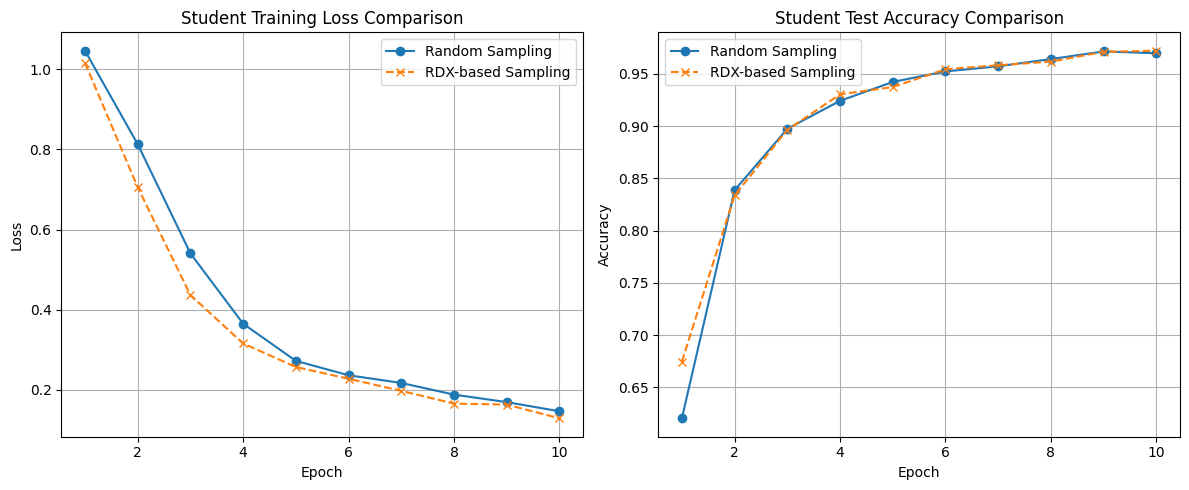

In [15]:
print("\n--- Plotting Training Progress Comparison ---")
epochs_range = range(1, STUDENT_NUM_EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, random_train_losses, label='Random Sampling', marker='o', linestyle='-')
plt.plot(epochs_range, rdx_train_losses, label='RDX-based Sampling', marker='x', linestyle='--')
plt.title('Student Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Test Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, random_test_accuracies, label='Random Sampling', marker='o', linestyle='-')
plt.plot(epochs_range, rdx_test_accuracies, label='RDX-based Sampling', marker='x', linestyle='--')
plt.title('Student Test Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()